# 06 — Compare Approach I vs Approach-II variants (interactive)

This notebook compares a **selected saved Approach-II variant** (for example `min2`, `min3`, `min4`, or a custom tag) with Approach I and, when available, the published/metadata reference annotation `final_CT`.

It also includes a **multi-threshold sensitivity analysis** across saved Approach-II variants. All figures are shown inline first. Saving is opt-in and versioned so different rule thresholds do not overwrite each other.


In [6]:
# ============================================================
# Dataset_02 CosMx — shared Jupyter initialization
# ============================================================
from pathlib import Path
import sys
import re, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc

CURRENT_DIR = Path.cwd().resolve()

def find_project_root(start: Path) -> Path:
    """Find the nearest parent containing both src/ and data/."""
    for candidate in [start, *start.parents]:
        if (candidate / "src").is_dir() and (candidate / "data").is_dir():
            return candidate
    raise FileNotFoundError(
        f"Could not locate project root from {start}. "
        "Expected a parent containing src/ and data/."
    )

PROJECT_ROOT = find_project_root(CURRENT_DIR)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

RAW_DIR = PROJECT_ROOT / "data" / "raw"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
SPATIAL_DIR = PROJECT_ROOT / "data" / "spatial"
RESULTS_DIR = PROJECT_ROOT / "results"
CONFIG_DIR = PROJECT_ROOT / "config"

sc.settings.verbosity = 2

print("=" * 70)
print("Dataset_02 CosMx Jupyter environment")
print("=" * 70)
print("Notebook directory :", CURRENT_DIR)
print("Project root       :", PROJECT_ROOT)
print("Python             :", sys.executable)
print("src exists         :", (PROJECT_ROOT / "src").exists())
print("processed exists   :", PROCESSED_DIR.exists())
print("spatial exists     :", SPATIAL_DIR.exists())


Dataset_02 CosMx Jupyter environment
Notebook directory : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/jupyter-2
Project root       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised
Python             : /home/jqu/.conda/envs/spatialdata/bin/python
src exists         : True
processed exists   : True
spatial exists     : True


## 1. Select one Approach-II variant
Change only `RULE_RUN_TAG` to compare a different saved result from Notebook 05.


In [7]:
# ============================================================
# Discover saved Approach-II variants, then select one — EDIT RULE_RUN_TAG
# ============================================================
VARIANT_ROOT = RESULTS_DIR / "FOV46" / "approach_ii_variants"

available_variants = {}
if VARIANT_ROOT.exists():
    for variant_dir in sorted(VARIANT_ROOT.iterdir()):
        if not variant_dir.is_dir():
            continue
        tag = variant_dir.name
        path = variant_dir / f"GSM9046088_FOV46_approach_i_ii_{tag}.h5ad"
        if path.exists():
            available_variants[tag] = path

if not available_variants:
    raise FileNotFoundError(
        "No saved Approach-II variants were found.\n\n"
        f"Searched:\n{VARIANT_ROOT}\n\n"
        "Go back to Notebook 05-2, set SAVE_ALL_SWEEP_VARIANTS=True, "
        "run the save cell, and confirm exists=True for the variants."
    )

print("Available saved Approach-II variants:")
for tag, path in available_variants.items():
    print(f"  {tag:12s} {path.stat().st_size / 1024**2:8.2f} MB")

# EDIT HERE after reviewing the available list above.
RULE_RUN_TAG = "min4"

if RULE_RUN_TAG not in available_variants:
    raise ValueError(
        f"Requested RULE_RUN_TAG={RULE_RUN_TAG!r} is not saved.\n"
        f"Available variants: {list(available_variants)}"
    )

INPUT_H5AD = available_variants[RULE_RUN_TAG]
variant_dir = INPUT_H5AD.parent
APPROACH_I = "cell_type_scanpy"
REFERENCE = "final_CT"

a = sc.read_h5ad(INPUT_H5AD)

# Resolve the rule column robustly. New files use cell_type_rule_<tag>; legacy
# files may contain only cell_type_rule.
preferred_rule_col = f"cell_type_rule_{RULE_RUN_TAG}"
if preferred_rule_col in a.obs.columns:
    APPROACH_II = preferred_rule_col
elif "cell_type_rule" in a.obs.columns:
    APPROACH_II = "cell_type_rule"
    print(f"WARNING: {preferred_rule_col!r} not found; using legacy 'cell_type_rule'.")
else:
    candidates = [c for c in a.obs.columns if c.startswith("cell_type_rule")]
    raise KeyError(
        f"No Approach-II rule column found for {RULE_RUN_TAG}. "
        f"Available rule columns: {candidates}"
    )

if APPROACH_I not in a.obs.columns:
    raise KeyError(f"Required Approach-I column {APPROACH_I!r} is missing.")

print("\nSelected variant :", RULE_RUN_TAG)
print("Input h5ad       :", INPUT_H5AD)
print("Approach I       :", APPROACH_I)
print("Approach II      :", APPROACH_II)
print("Reference present:", REFERENCE in a.obs.columns)
print(a)


Available saved Approach-II variants:
  min2             3.61 MB
  min3             3.61 MB
  min4             3.61 MB
  min5             3.61 MB

Selected variant : min4
Input h5ad       : /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min4/GSM9046088_FOV46_approach_i_ii_min4.h5ad
Approach I       : cell_type_scanpy
Approach II      : cell_type_rule_min4
Reference present: False
AnnData object with n_obs × n_vars = 938 × 1000
    obs: 'fov', 'cell_ID', 'Area', 'AspectRatio', 'CenterX_local_px', 'CenterY_local_px', 'CenterX_global_px', 'CenterY_global_px', 'Width', 'Height', 'Mean.PanCK', 'Max.PanCK', 'Mean.CD68', 'Max.CD68', 'Mean.B2M.MembraneStain', 'Max.B2M.MembraneStain', 'Mean.CD45', 'Max.CD45', 'Mean.DAPI', 'Max.DAPI', 'n_genes_by_counts', 'total_counts', 'control_counts', 'control_fraction', 'qc_cell_area', 'qc_low_count_within_fov', 'qc_low_gene_within_f

## 2. Summary of the selected variant
This reports exact string agreement, and the fractions of Approach-II cells that are `Unassigned` or `Ambiguous`. Exact agreement is descriptive because the two approaches can use different annotation granularity.


In [8]:
# ============================================================
# Selected-variant summary
# ============================================================
i_labels = a.obs[APPROACH_I].astype(str)
ii_labels = a.obs[APPROACH_II].astype(str)

selected_summary = pd.Series({
    "rule_run_tag": RULE_RUN_TAG,
    "n_cells": int(a.n_obs),
    "approach_i_vs_ii_exact_agreement_fraction": float((i_labels == ii_labels).mean()),
    "approach_ii_assigned_fraction": float((~ii_labels.isin(["Unassigned", "Ambiguous"])).mean()),
    "approach_ii_unassigned_fraction": float(ii_labels.eq("Unassigned").mean()),
    "approach_ii_ambiguous_fraction": float(ii_labels.eq("Ambiguous").mean()),
})

display(selected_summary.to_frame("value"))
print("\nApproach II label counts:")
display(a.obs[APPROACH_II].value_counts(dropna=False).to_frame("n_cells"))


,value
rule_run_tag,min4
n_cells,938
approach_i_vs_ii_exact_agreement_fraction,0.228145
approach_ii_assigned_fraction,0.272921
approach_ii_unassigned_fraction,0.700426
approach_ii_ambiguous_fraction,0.026652



Approach II label counts:


,n_cells
cell_type_rule_min4,
Unassigned,657
Macrophage,145
Fibroblast,71
Epithelial,39
Ambiguous,25
Mural,1


## 3. Contingency / concordance comparisons
For each pair, the notebook displays raw cell counts and the row-normalized table, then shows the same normalized data as a heatmap and a 100% stacked bar.


In [9]:
# ============================================================
# Comparison helpers
# ============================================================
def contingency_tables(data, row_col, col_col):
    counts = pd.crosstab(data.obs[row_col], data.obs[col_col], dropna=False)
    row_fraction = pd.crosstab(
        data.obs[row_col], data.obs[col_col], normalize="index", dropna=False
    )
    return counts, row_fraction


def comparison_figure(row_fraction, row_label, col_label, title):
    width = max(15, 0.75 * row_fraction.shape[1] + 10)
    height = max(6, 0.5 * row_fraction.shape[0] + 4)
    fig, axes = plt.subplots(1, 2, figsize=(width, height))

    im = axes[0].imshow(
        row_fraction.to_numpy(), aspect="auto", vmin=0, vmax=1
    )
    axes[0].set_xticks(
        range(row_fraction.shape[1]), row_fraction.columns.astype(str),
        rotation=45, ha="right"
    )
    axes[0].set_yticks(
        range(row_fraction.shape[0]), row_fraction.index.astype(str)
    )
    axes[0].set_xlabel(col_label)
    axes[0].set_ylabel(row_label)
    axes[0].set_title("Row-normalized concordance")
    fig.colorbar(im, ax=axes[0], label="Fraction")

    row_fraction.plot(
        kind="bar", stacked=True, ax=axes[1], width=0.85
    )
    axes[1].set_ylim(0, 1)
    axes[1].set_ylabel("Fraction of cells")
    axes[1].set_xlabel(row_label)
    axes[1].set_title("100% stacked composition")
    axes[1].legend(
        title=col_label, bbox_to_anchor=(1.02, 1),
        loc="upper left", frameon=False
    )

    fig.suptitle(title, y=1.02)
    fig.tight_layout()
    return fig


def show_comparison(data, row_col, col_col, row_label, col_label, title):
    counts, frac = contingency_tables(data, row_col, col_col)
    print("Raw contingency counts")
    display(counts)
    print("Row-normalized concordance")
    display(frac.round(3))
    fig = comparison_figure(frac, row_label, col_label, title)
    plt.show()
    return counts, frac, fig


Raw contingency counts


cell_type_rule_min4,Ambiguous,Epithelial,Fibroblast,Macrophage,Mural,Unassigned
cell_type_scanpy,,,,,,
Endothelial,0,0,2,0,1,21
Epithelial,6,39,3,3,0,90
Fibroblast,9,0,50,7,0,71
Macrophage,9,0,9,125,0,99
Plasma_cell,1,0,7,10,0,376


Row-normalized concordance


cell_type_rule_min4,Ambiguous,Epithelial,Fibroblast,Macrophage,Mural,Unassigned
cell_type_scanpy,,,,,,
Endothelial,0.000,0.000,0.083,0.000,0.042,0.875
Epithelial,0.043,0.277,0.021,0.021,0.000,0.638
Fibroblast,0.066,0.000,0.365,0.051,0.000,0.518
Macrophage,0.037,0.000,0.037,0.517,0.000,0.409
Plasma_cell,0.003,0.000,0.018,0.025,0.000,0.954


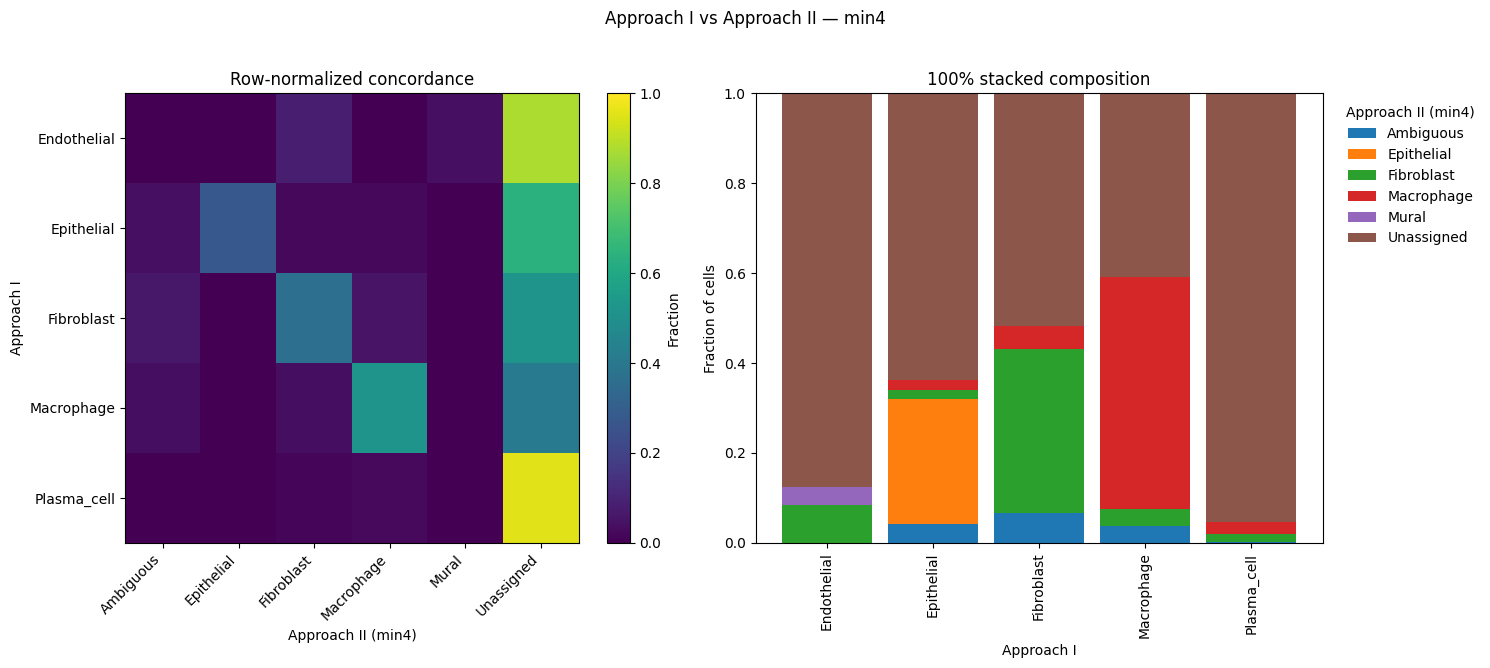

In [10]:
# Approach I vs selected Approach II
ct_i_ii, frac_i_ii, fig_i_ii = show_comparison(
    a,
    APPROACH_I,
    APPROACH_II,
    "Approach I",
    f"Approach II ({RULE_RUN_TAG})",
    f"Approach I vs Approach II — {RULE_RUN_TAG}",
)


In [11]:
# Reference comparisons, if final_CT is available.
ct_ref_i = frac_ref_i = fig_ref_i = None
ct_ref_ii = frac_ref_ii = fig_ref_ii = None

if REFERENCE in a.obs.columns:
    print("Reference vs Approach I")
    ct_ref_i, frac_ref_i, fig_ref_i = show_comparison(
        a, REFERENCE, APPROACH_I,
        "Reference final_CT", "Approach I",
        "Reference final_CT vs Approach I",
    )

    print("\nReference vs Approach II")
    ct_ref_ii, frac_ref_ii, fig_ref_ii = show_comparison(
        a, REFERENCE, APPROACH_II,
        "Reference final_CT", f"Approach II ({RULE_RUN_TAG})",
        f"Reference final_CT vs Approach II — {RULE_RUN_TAG}",
    )
else:
    print("final_CT not found; reference comparisons skipped.")


final_CT not found; reference comparisons skipped.


## 4. UMAP comparison
All panels use the same `X_umap` coordinates and a consistent Scanpy theme with visible axes.


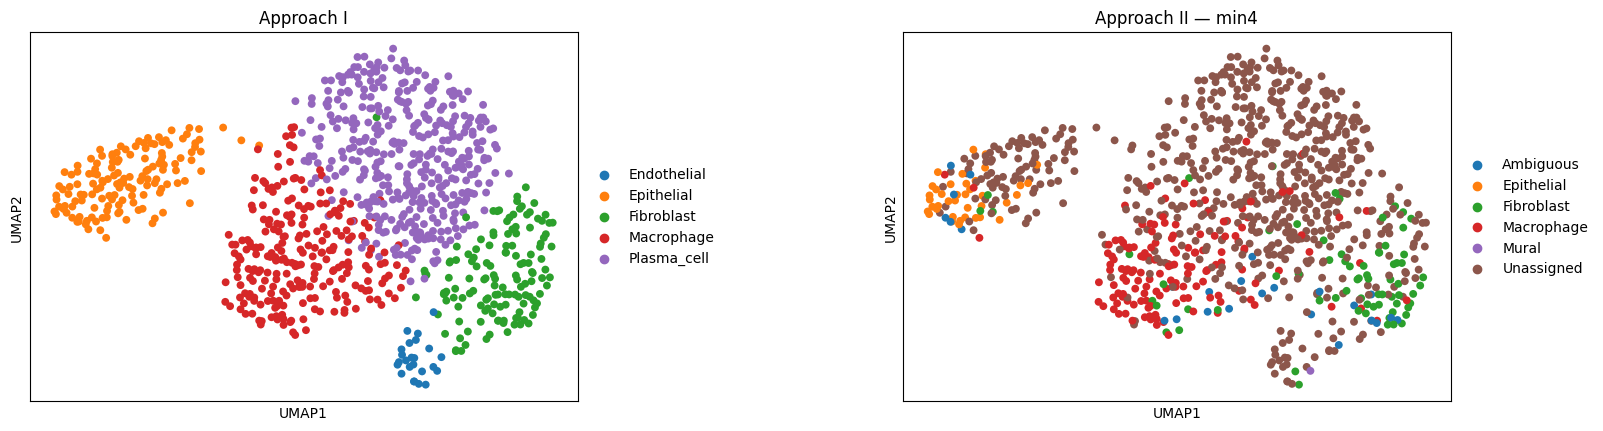

In [12]:
# ============================================================
# UMAP comparison
# ============================================================
if "X_umap" not in a.obsm:
    raise KeyError("X_umap is missing from this saved variant.")

umap_cols = [APPROACH_I, APPROACH_II]
umap_titles = ["Approach I", f"Approach II — {RULE_RUN_TAG}"]
if REFERENCE in a.obs.columns:
    umap_cols.append(REFERENCE)
    umap_titles.append("Reference final_CT")

sc.pl.umap(
    a,
    color=umap_cols,
    frameon=True,
    wspace=0.45,
    legend_loc="right margin",
    title=umap_titles,
    show=True,
)


## 5. Spatial coordinate comparison
This uses cell-center coordinates from `obsm['spatial']`.


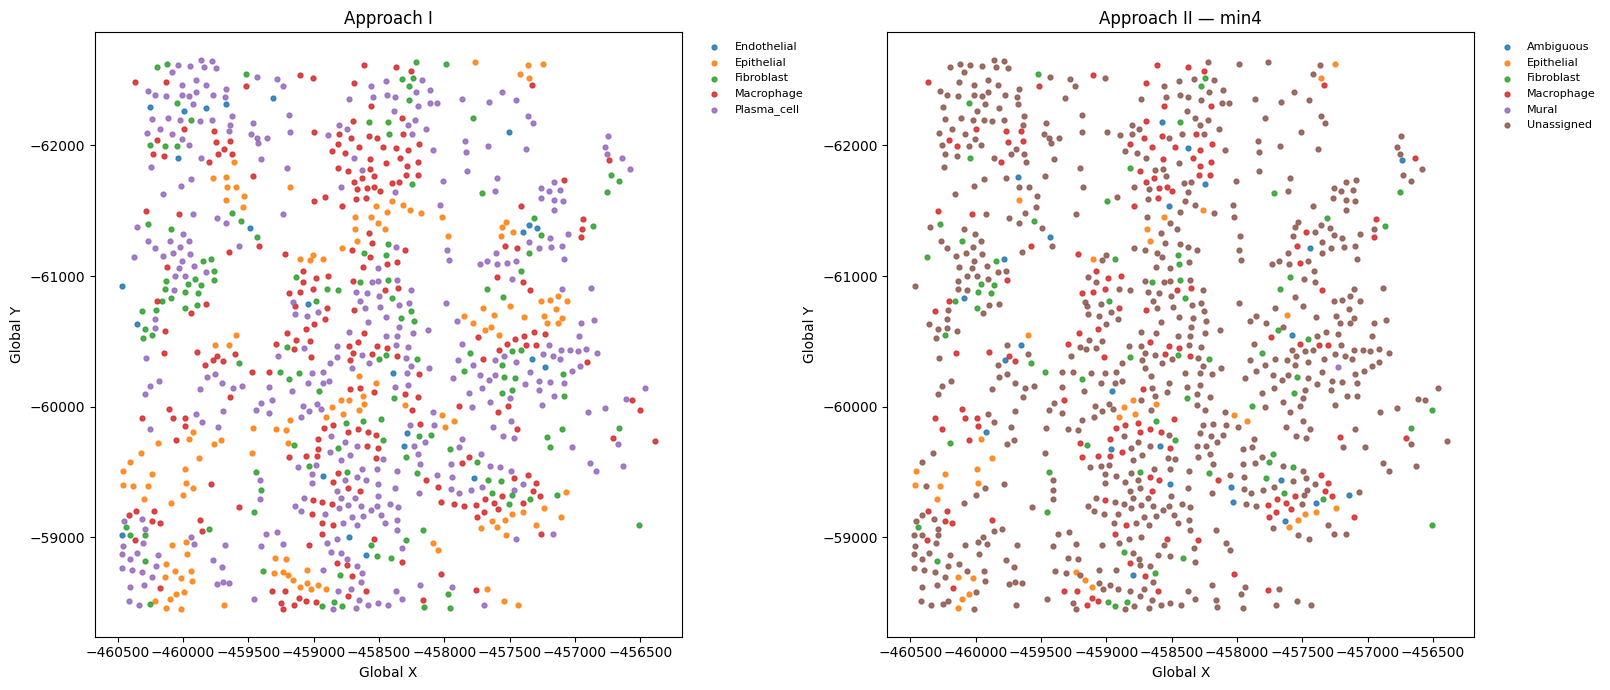

In [13]:
# ============================================================
# Spatial coordinate helper
# ============================================================
def spatial_coordinate_figure(data, columns, titles=None, point_size=12):
    if "spatial" not in data.obsm:
        raise KeyError("obsm['spatial'] is missing.")

    xy = np.asarray(data.obsm["spatial"])
    titles = titles or columns
    fig, axes = plt.subplots(1, len(columns), figsize=(8 * len(columns), 7))
    axes = np.atleast_1d(axes)

    for ax, col, title in zip(axes, columns, titles):
        labels = data.obs[col].astype("category")
        label_str = labels.astype(str).to_numpy()
        for cat in labels.cat.categories:
            mask = label_str == str(cat)
            ax.scatter(
                xy[mask, 0], xy[mask, 1], s=point_size,
                label=str(cat), alpha=0.85
            )
        ax.set_aspect("equal")
        ax.invert_yaxis()
        ax.set_xlabel("Global X coordinate (px)")
        ax.set_ylabel("Global Y coordinate (px)")
        ax.set_title(title)
        ax.legend(
            bbox_to_anchor=(1.02, 1), loc="upper left",
            frameon=False, fontsize=8
        )

    fig.tight_layout()
    return fig

spatial_cols = [APPROACH_I, APPROACH_II]
spatial_titles = ["Approach I", f"Approach II — {RULE_RUN_TAG}"]
if REFERENCE in a.obs.columns:
    spatial_cols.append(REFERENCE)
    spatial_titles.append("Reference final_CT")

fig_spatial_coordinates = spatial_coordinate_figure(
    a, spatial_cols, spatial_titles, point_size=12
)
plt.show()


## 6. Cell-segmentation spatial maps
If the FOV46 SpatialData Zarr exists, this section uses the shared `src.plotting` helper to produce both **filled segmentation polygons** and **white-outline segmentation maps with annotation-colored cell centers**. If the helper signature in your local `src/plotting.py` differs, the notebook reports the error without affecting the comparison tables above.


In [14]:
# ============================================================
# Optional SpatialData segmentation visualization
# ============================================================
SDATA_FOV46 = SPATIAL_DIR / "GSM9046088_CosMx_FOV46.zarr"
print("FOV46 SpatialData:", SDATA_FOV46)
print("Exists           :", SDATA_FOV46.exists())

segmentation_generated = False

if SDATA_FOV46.exists():
    try:
        import spatialdata as sd
        import spatialdata_plot  # noqa: F401
        from src.plotting import plot_spatial_annotation_pair

        S46 = sd.read_zarr(SDATA_FOV46)
        print("SpatialData loaded. Elements:")
        print("  Shapes:", list(S46.shapes.keys()))
        print("  Tables:", list(S46.tables.keys()))

        # Do not print(S46): whole-slide/FOV Dask repr can be version-sensitive.
        # The helper creates coordinate, filled-segment, and outline versions.
        preview_dir = RESULTS_DIR / "FOV46" / "_interactive_preview_06"
        preview_dir.mkdir(parents=True, exist_ok=True)

        for col, label in [
            (APPROACH_I, "approach_i"),
            (APPROACH_II, f"approach_ii_{RULE_RUN_TAG}"),
            *([(REFERENCE, "reference_final_CT")] if REFERENCE in a.obs.columns else []),
        ]:
            print(f"Rendering segmentation preview: {label}")
            plot_spatial_annotation_pair(
                a,
                S46,
                col,
                preview_dir,
                prefix=label,
            )

        segmentation_generated = True
        print("Segmentation preview files:", preview_dir)
        print("If your helper displays figures inline, they appear above; otherwise open the PNGs from this directory.")

    except Exception as exc:
        print("Segmentation visualization skipped because the helper call failed:")
        print(repr(exc))
        print("The UMAP, coordinate maps, and comparison statistics remain valid.")
else:
    print("FOV46 SpatialData not found; segmentation maps skipped.")


FOV46 SpatialData: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/data/spatial/GSM9046088_CosMx_FOV46.zarr
Exists           : True
SpatialData loaded. Elements:
  Shapes: ['cell_boundaries']
  Tables: ['table']
Rendering segmentation preview: approach_i
Segmentation visualization skipped because the helper call failed:
TypeError("unsupported operand type(s) for +: 'SpatialData' and 'str'")
The UMAP, coordinate maps, and comparison statistics remain valid.


## 7. Multi-threshold sensitivity analysis
This section scans saved Approach-II variants (for example `min2`–`min5`) and compares their assignment rates and exact agreement with Approach I. Missing variants are skipped.


In [15]:
# ============================================================
# Multi-threshold sensitivity analysis across ACTUALLY SAVED variants
# ============================================================
sensitivity_rows = []
sensitivity_objects = {}

for tag, path in available_variants.items():
    obj = sc.read_h5ad(path)
    preferred = f"cell_type_rule_{tag}"
    if preferred in obj.obs.columns:
        ii_col = preferred
    elif "cell_type_rule" in obj.obs.columns:
        ii_col = "cell_type_rule"
    else:
        print(f"SKIP {tag}: no rule annotation column")
        continue

    if APPROACH_I not in obj.obs.columns:
        print(f"SKIP {tag}: {APPROACH_I!r} missing")
        continue

    i_lab = obj.obs[APPROACH_I].astype(str)
    ii_lab = obj.obs[ii_col].astype(str)
    assigned = ~ii_lab.isin(["Unassigned", "Ambiguous"])

    # Parse minN when possible; keep NaN for custom tags.
    m = re.match(r"^min(\d+)", tag)
    min_positive = int(m.group(1)) if m else np.nan

    sensitivity_rows.append({
        "rule_run_tag": tag,
        "min_positive_genes": min_positive,
        "n_cells": int(obj.n_obs),
        "assigned_fraction": float(assigned.mean()),
        "unassigned_fraction": float(ii_lab.eq("Unassigned").mean()),
        "ambiguous_fraction": float(ii_lab.eq("Ambiguous").mean()),
        "exact_agreement_with_approach_i": float((i_lab == ii_lab).mean()),
        "n_rule_labels_observed": int(ii_lab.nunique()),
    })
    sensitivity_objects[tag] = obj

sensitivity_df = pd.DataFrame(sensitivity_rows)
if sensitivity_df.empty:
    print("No valid saved sensitivity variants were found.")
else:
    sensitivity_df = sensitivity_df.sort_values(
        ["min_positive_genes", "rule_run_tag"], na_position="last"
    ).reset_index(drop=True)
    display(sensitivity_df)


,rule_run_tag,min_positive_genes,n_cells,assigned_fraction,unassigned_fraction,ambiguous_fraction,exact_agreement_with_approach_i,n_rule_labels_observed
0,min2,2,938,0.330490,0.089552,0.579957,0.270789,10
1,min3,3,938,0.459488,0.352878,0.187633,0.385928,7
2,min4,4,938,0.272921,0.700426,0.026652,0.228145,6
3,min5,5,938,0.067164,0.931770,0.001066,0.057569,4


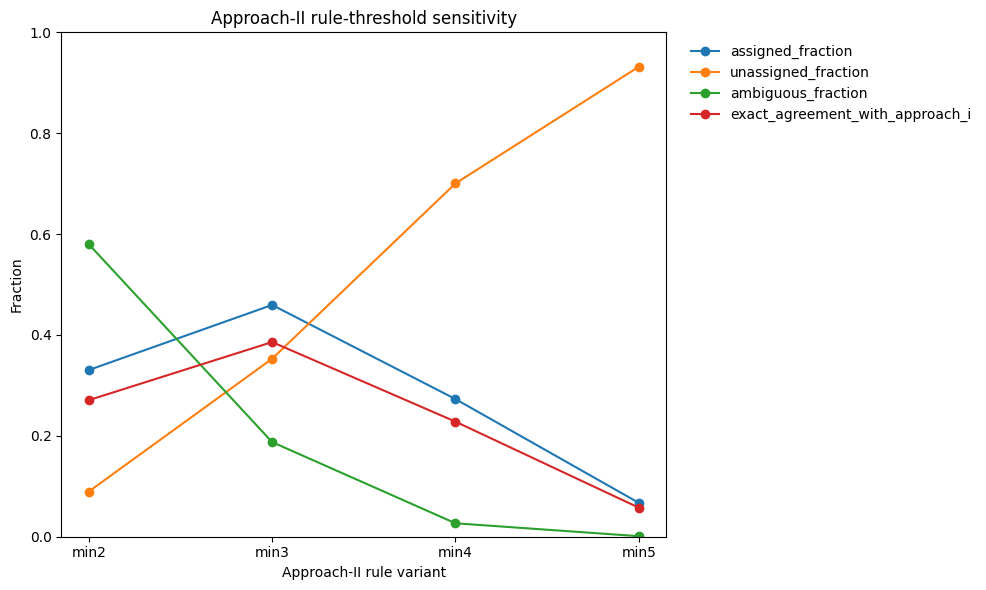

In [16]:
# Visualize threshold sensitivity.
if not sensitivity_df.empty:
    plot_cols = [
        "assigned_fraction",
        "unassigned_fraction",
        "ambiguous_fraction",
        "exact_agreement_with_approach_i",
    ]
    fig, ax = plt.subplots(figsize=(10, 6))
    x = np.arange(len(sensitivity_df))
    for col in plot_cols:
        ax.plot(x, sensitivity_df[col], marker="o", label=col)
    ax.set_xticks(x, sensitivity_df["rule_run_tag"])
    ax.set_ylim(0, 1)
    ax.set_xlabel("Approach-II rule variant")
    ax.set_ylabel("Fraction")
    ax.set_title("Approach-II rule-threshold sensitivity")
    ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", frameon=False)
    fig.tight_layout()
    plt.show()


Saved figure:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/comparisons/threshold_sensitivity/approach_ii_rule_threshold_sensitivity.png


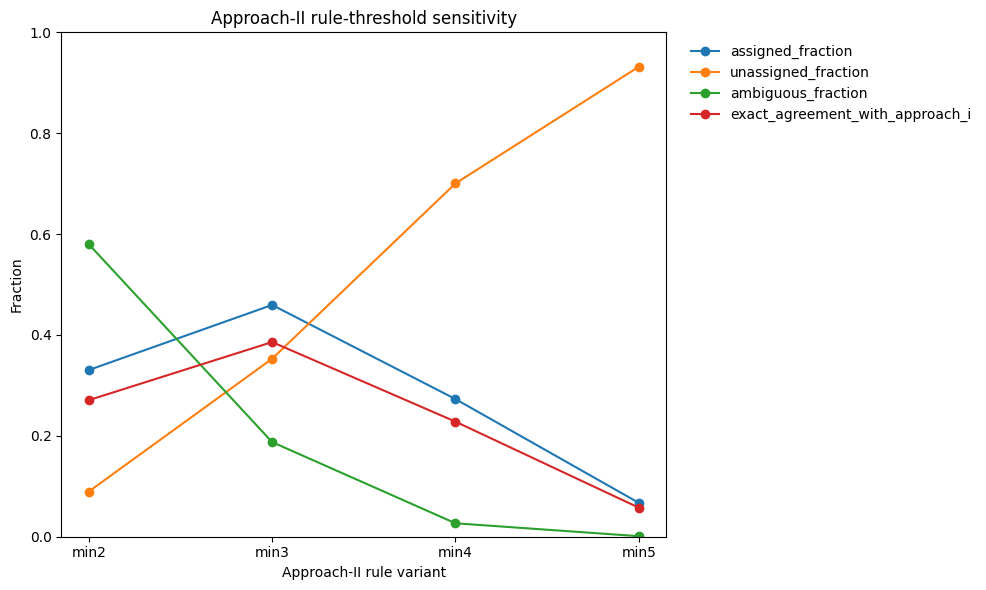

In [21]:
# ============================================================
# Visualize and optionally save threshold sensitivity
# ============================================================

SAVE_SENSITIVITY_FIGURE = True

SENSITIVITY_FIGURE_DIR = (
    RESULTS_DIR
    / "FOV46"
    / "comparisons"
    / "threshold_sensitivity"
)

SENSITIVITY_FIGURE_FILE = (
    SENSITIVITY_FIGURE_DIR
    / "approach_ii_rule_threshold_sensitivity.png"
)


if not sensitivity_df.empty:

    plot_cols = [
        "assigned_fraction",
        "unassigned_fraction",
        "ambiguous_fraction",
        "exact_agreement_with_approach_i",
    ]

    fig, ax = plt.subplots(
        figsize=(10, 6)
    )

    x = np.arange(
        len(sensitivity_df)
    )

    for col in plot_cols:

        ax.plot(
            x,
            sensitivity_df[col],
            marker="o",
            label=col,
        )

    ax.set_xticks(
        x,
        sensitivity_df["rule_run_tag"],
    )

    ax.set_ylim(0, 1)

    ax.set_xlabel(
        "Approach-II rule variant"
    )

    ax.set_ylabel(
        "Fraction"
    )

    ax.set_title(
        "Approach-II rule-threshold sensitivity"
    )

    ax.legend(
        bbox_to_anchor=(1.02, 1),
        loc="upper left",
        frameon=False,
    )

    fig.tight_layout()


    # --------------------------------------------------------
    # Save
    # --------------------------------------------------------

    if SAVE_SENSITIVITY_FIGURE:

        SENSITIVITY_FIGURE_DIR.mkdir(
            parents=True,
            exist_ok=True,
        )

        fig.savefig(
            SENSITIVITY_FIGURE_FILE,
            dpi=300,
            bbox_inches="tight",
        )

        print(
            "Saved figure:"
        )

        print(
            SENSITIVITY_FIGURE_FILE
        )


    # --------------------------------------------------------
    # Display inline
    # --------------------------------------------------------

    plt.show()

## 8. Versioned export
Saving is **off by default**. The output directory includes the selected rule tag, so `min2`, `min3`, and `min4` comparisons remain separate.


In [17]:
# ============================================================
# Versioned comparison output configuration
# ============================================================
SAVE_COMPARISON = False
COMPARISON_TAG = f"approach_i_vs_{RULE_RUN_TAG}"
COMPARISON_OUTPUT_DIR = variant_dir / "comparison" / COMPARISON_TAG

print("SAVE_COMPARISON :", SAVE_COMPARISON)
print("COMPARISON_TAG  :", COMPARISON_TAG)
print("Output directory:", COMPARISON_OUTPUT_DIR)
print("Currently exists:", COMPARISON_OUTPUT_DIR.exists())

planned_files = [
    COMPARISON_OUTPUT_DIR / f"approach_i_vs_ii_counts_{RULE_RUN_TAG}.csv",
    COMPARISON_OUTPUT_DIR / f"approach_i_vs_ii_row_fraction_{RULE_RUN_TAG}.csv",
    COMPARISON_OUTPUT_DIR / f"typing_summary_{RULE_RUN_TAG}.csv",
    COMPARISON_OUTPUT_DIR / f"approach_i_vs_ii_concordance_{RULE_RUN_TAG}.png",
    COMPARISON_OUTPUT_DIR / f"spatial_coordinates_{RULE_RUN_TAG}.png",
]
if not sensitivity_df.empty:
    planned_files.append(COMPARISON_OUTPUT_DIR / "approach_ii_threshold_sensitivity.csv")

print("\nPlanned outputs:")
for p in planned_files:
    print(" -", p.name)


SAVE_COMPARISON : False
COMPARISON_TAG  : approach_i_vs_min4
Output directory: /research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min4/comparison/approach_i_vs_min4
Currently exists: False

Planned outputs:
 - approach_i_vs_ii_counts_min4.csv
 - approach_i_vs_ii_row_fraction_min4.csv
 - typing_summary_min4.csv
 - approach_i_vs_ii_concordance_min4.png
 - spatial_coordinates_min4.png
 - approach_ii_threshold_sensitivity.csv


In [19]:
# ============================================================
# Save only after you are satisfied with the interactive result
# ============================================================
SAVE_COMPARISON = True

if SAVE_COMPARISON:
    COMPARISON_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    ct_i_ii.to_csv(
        COMPARISON_OUTPUT_DIR / f"approach_i_vs_ii_counts_{RULE_RUN_TAG}.csv"
    )
    frac_i_ii.to_csv(
        COMPARISON_OUTPUT_DIR / f"approach_i_vs_ii_row_fraction_{RULE_RUN_TAG}.csv"
    )
    selected_summary.to_csv(
        COMPARISON_OUTPUT_DIR / f"typing_summary_{RULE_RUN_TAG}.csv",
        header=["value"],
    )

    fig_i_ii.savefig(
        COMPARISON_OUTPUT_DIR / f"approach_i_vs_ii_concordance_{RULE_RUN_TAG}.png",
        dpi=250, bbox_inches="tight"
    )
    fig_spatial_coordinates.savefig(
        COMPARISON_OUTPUT_DIR / f"spatial_coordinates_{RULE_RUN_TAG}.png",
        dpi=250, bbox_inches="tight"
    )

    if REFERENCE in a.obs.columns:
        ct_ref_i.to_csv(
            COMPARISON_OUTPUT_DIR / f"reference_vs_approach_i_counts_{RULE_RUN_TAG}.csv"
        )
        frac_ref_i.to_csv(
            COMPARISON_OUTPUT_DIR / f"reference_vs_approach_i_row_fraction_{RULE_RUN_TAG}.csv"
        )
        ct_ref_ii.to_csv(
            COMPARISON_OUTPUT_DIR / f"reference_vs_approach_ii_counts_{RULE_RUN_TAG}.csv"
        )
        frac_ref_ii.to_csv(
            COMPARISON_OUTPUT_DIR / f"reference_vs_approach_ii_row_fraction_{RULE_RUN_TAG}.csv"
        )
        fig_ref_i.savefig(
            COMPARISON_OUTPUT_DIR / f"reference_vs_approach_i_concordance_{RULE_RUN_TAG}.png",
            dpi=250, bbox_inches="tight"
        )
        fig_ref_ii.savefig(
            COMPARISON_OUTPUT_DIR / f"reference_vs_approach_ii_concordance_{RULE_RUN_TAG}.png",
            dpi=250, bbox_inches="tight"
        )

    if not sensitivity_df.empty:
        sensitivity_df.to_csv(
            COMPARISON_OUTPUT_DIR / "approach_ii_threshold_sensitivity.csv",
            index=False,
        )

    print("Saved comparison outputs:")
    print(COMPARISON_OUTPUT_DIR)
else:
    print("SAVE_COMPARISON=False — results remain interactive/in memory only.")


Saved comparison outputs:
/research/rgs01/home/clusterHome/jqu/activities/learning/BioHackathon/BioHackathon-2026/Dataset_02_CosMx_revised/Dataset_02_CosMx_revised/results/FOV46/approach_ii_variants/min4/comparison/approach_i_vs_min4


In [20]:
# ============================================================
# Verify saved outputs
# ============================================================
print("Comparison directory exists:", COMPARISON_OUTPUT_DIR.exists())

if COMPARISON_OUTPUT_DIR.exists():
    print("\nFiles:")
    for path in sorted(COMPARISON_OUTPUT_DIR.iterdir()):
        if path.is_file():
            size_mb = path.stat().st_size / 1024**2
            print(f"  {path.name:70s} {size_mb:8.3f} MB")


Comparison directory exists: True

Files:
  approach_i_vs_ii_concordance_min4.png                                     0.225 MB
  approach_i_vs_ii_counts_min4.csv                                          0.000 MB
  approach_i_vs_ii_row_fraction_min4.csv                                    0.001 MB
  approach_ii_threshold_sensitivity.csv                                     0.000 MB
  spatial_coordinates_min4.png                                              0.671 MB
  typing_summary_min4.csv                                                   0.000 MB
